# Analysis Pruning

In [6]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

### Setup

In [4]:
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (12, 6)

fig_dir = Path('../results/figures/pruning')
fig_dir.mkdir(parents=True, exist_ok=True)

target_files = ["pruned_10pct.json", "pruned_30pct.json", "pruned_50pct.json", "pruned_70pct.json"]
metrics_dir = Path('../results/metrics')

data = []
for file_name in target_files:
    file_path = metrics_dir / file_name
    if file_path.exists():
        with open(file_path, 'r') as f:
            data.append(json.load(f))
    else:
        print(f"Missing: {file_path}")

if not data:
    raise ValueError("Data empty, check path folder")

df_summary = pd.DataFrame(data)
print(f"Load json file into dataframe successfully.")
df_summary

Load json file into dataframe successfully.


,label,ttft_p50_ms,ttft_p90_ms,ttft_p99_ms,ttft_mean_ms,itl_p50_ms,itl_p90_ms,itl_p99_ms,itl_mean_ms,itl_std_ms,itl_per_position,tpot_mean_ms,e2e_ms,throughput_tps,mean_n_generated,peak_memory_mb,perplexity,n_runs,trace_path,timestamp
0,pruned_10pct,40.901808,43.425688,43.993561,39.157901,27.908469,38.513219,48.176683,30.691569,5.394451,"[38.511564000032195, 62.330029000008835, 30.16...",30.691569,3108.314812,32.582238,100.0,3588.990234,7.830222,3,None,2026-03-15 05:26:58
1,pruned_30pct,43.362407,45.574805,46.072594,44.187095,28.007322,36.540485,45.449737,30.144781,4.680907,"[50.12651399999868, 39.16644100002031, 37.8387...",30.144781,3058.665232,33.173238,100.0,3587.990234,8.167657,3,None,2026-03-15 05:27:31
2,pruned_50pct,33.300447,37.597577,38.564431,35.026225,28.532585,39.172003,47.705763,31.457743,5.491743,"[32.13767900001585, 27.765773999931298, 27.444...",31.457743,3180.800561,31.788676,100.0,3587.990234,11.819548,3,None,2026-03-15 05:28:05
3,pruned_70pct,36.131426,36.716510,36.848154,35.250195,28.134231,40.461614,51.947231,31.647125,6.031704,"[32.96529899989764, 28.042712000001302, 27.530...",31.647125,3199.962745,31.598446,100.0,3587.990234,246.603668,3,None,2026-03-15 05:28:38


### The VRAM Illusion

Pictures saved in  {WindowsPath('../results/figures/pruning/memory_footprint.png')}


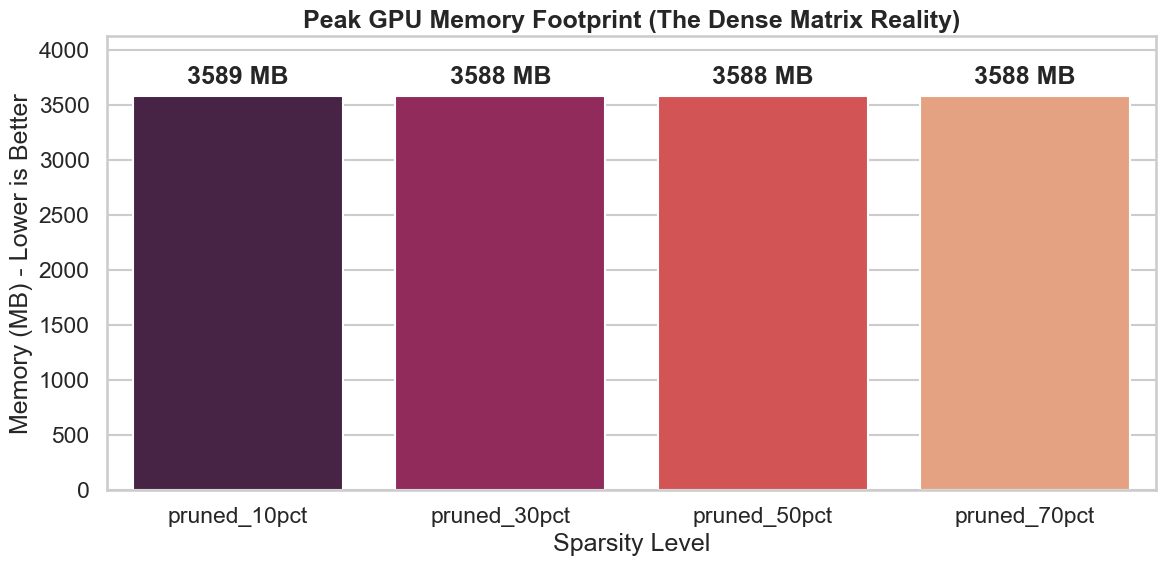

In [7]:
ax = sns.barplot(data=df_summary, x='label', y='peak_memory_mb', palette='rocket')

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f MB", label_type='edge', padding=5, fontweight='bold')

plt.title('Peak GPU Memory Footprint (The Dense Matrix Reality)', fontweight='bold')
plt.xlabel('Sparsity Level')
plt.ylabel('Memory (MB) - Lower is Better')

max_mem = df_summary['peak_memory_mb'].max()
plt.ylim(0, max_mem * 1.15)

plt.tight_layout()

# Save picture

save_path = fig_dir / "memory_footprint.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print("Pictures saved in ", {save_path})

plt.show()